# Import the Libraries

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Download Historical Data

In [14]:
assets = [
    'RELIANCE.NS',
    'TCS.NS',
    'HDFCBANK.NS',
    'INFY.NS'
]
start_date = '2021-01-01'
end_date = '2026-01-01'
prices = yf.download(
    assets,
    start=start_date,
    end=end_date,
    auto_adjust=True
)['Close']
prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2021-01-01,663.905701,1086.097290,897.047058,2521.074219
2021-01-04,659.689514,1110.051880,898.559143,2616.811279
2021-01-05,664.674316,1114.834229,887.388306,2662.915771
2021-01-06,661.809204,1104.752319,863.986023,2627.186523
2021-01-07,659.805908,1087.562134,862.586914,2611.086182


# Calculate daily returns

In [15]:
returns = prices.pct_change().dropna()
returns.head()

Ticker,HDFCBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,
2021-01-04,-0.006351,0.022056,0.001686,0.037975
2021-01-05,0.007556,0.004308,-0.012432,0.017619
2021-01-06,-0.004311,-0.009043,-0.026372,-0.013417
2021-01-07,-0.003027,-0.015560,-0.001619,-0.006128
2021-01-08,0.010874,0.039575,0.011799,0.029049


# Generate random Portfiolio Weights

In [16]:
np.random.seed(42)
weights = np.random.random(len(assets))
weights = weights / weights.sum()
weights_df = pd.DataFrame({
    'Asset': assets,
    'Weight': weights
})
print("Portfolio Weights")
display(weights_df)

Portfolio Weights


,Asset,Weight
0,RELIANCE.NS,0.141022
1,TCS.NS,0.357962
2,HDFCBANK.NS,0.275610
3,INFY.NS,0.225406


# Calculate Portfolio Returns

In [17]:
portfolio_returns = (returns * weights).sum(axis=1)
portfolio_returns.head()

Date
2021-01-04    0.016024
2021-01-05    0.003153
2021-01-06   -0.014138
2021-01-07   -0.007825
2021-01-08    0.025500
dtype: float64

# Portfolio Statistics

In [18]:
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
print(f"Mean Daily Return : {mu:.4%}")
print(f"Daily Volatility  : {sigma:.4%}")

Mean Daily Return : 0.0415%
Daily Volatility  : 1.0567%


# Historical VaR (95%)

confidence_level = 95
historical_var_return = np.percentile(
    portfolio_returns,
    100 - confidence_level
)
historical_var = abs(historical_var_return)
print(f"Historical VaR (95%): {historical_var:.4%}")

# Parametric VaR (95%)

In [20]:
z_score = norm.ppf(0.05)
parametric_var_return = mu + z_score * sigma
parametric_var = abs(parametric_var_return)
print(f"Parametric VaR (95%): {parametric_var:.4%}")

Parametric VaR (95%): 1.6966%


# Monte Carlo VaR (95%)

In [21]:
num_simulations = 10000
simulated_returns = np.random.normal(
    mu,
    sigma,
    num_simulations
)
mc_var_return = np.percentile(
    simulated_returns,
    5
)
mc_var = abs(mc_var_return)
print(f"Monte Carlo VaR (95%): {mc_var:.4%}")

Monte Carlo VaR (95%): 1.7071%


# Expected Shortfall

In [22]:
cvar_return = portfolio_returns[
    portfolio_returns <= historical_var_return
].mean()
cvar = abs(cvar_return)
print(f"Expected Shortfall (CVaR): {cvar:.4%}")

Expected Shortfall (CVaR): 2.3249%


# VaR Backtesting

In [23]:
breaches = portfolio_returns < historical_var_return
num_breaches = breaches.sum()
total_observations = len(portfolio_returns)
breach_rate = (
    num_breaches /
    total_observations
) * 100
print("VaR Backtesting Results")
print("-" * 40)
print(f"Total Observations : {total_observations}")
print(f"VaR Breaches       : {num_breaches}")
print(f"Breach Rate        : {breach_rate:.2f}%")
print(f"Expected Rate      : 5.00%")

VaR Backtesting Results
----------------------------------------
Total Observations : 1235
VaR Breaches       : 62
Breach Rate        : 5.02%
Expected Rate      : 5.00%


# Monetary Loss Estimation

In [24]:
portfolio_value = 100000
print(f"Portfolio Value: ₹{portfolio_value:,.0f}")
print()
print(f"Historical VaR Loss : ₹{historical_var * portfolio_value:,.2f}")
print(f"Parametric VaR Loss : ₹{parametric_var * portfolio_value:,.2f}")
print(f"Monte Carlo VaR Loss: ₹{mc_var * portfolio_value:,.2f}")
print(f"CVaR Loss           : ₹{cvar * portfolio_value:,.2f}")

Portfolio Value: ₹100,000

Historical VaR Loss : ₹1,663.50
Parametric VaR Loss : ₹1,696.57
Monte Carlo VaR Loss: ₹1,707.14
CVaR Loss           : ₹2,324.92


# Risk distribution Visualization

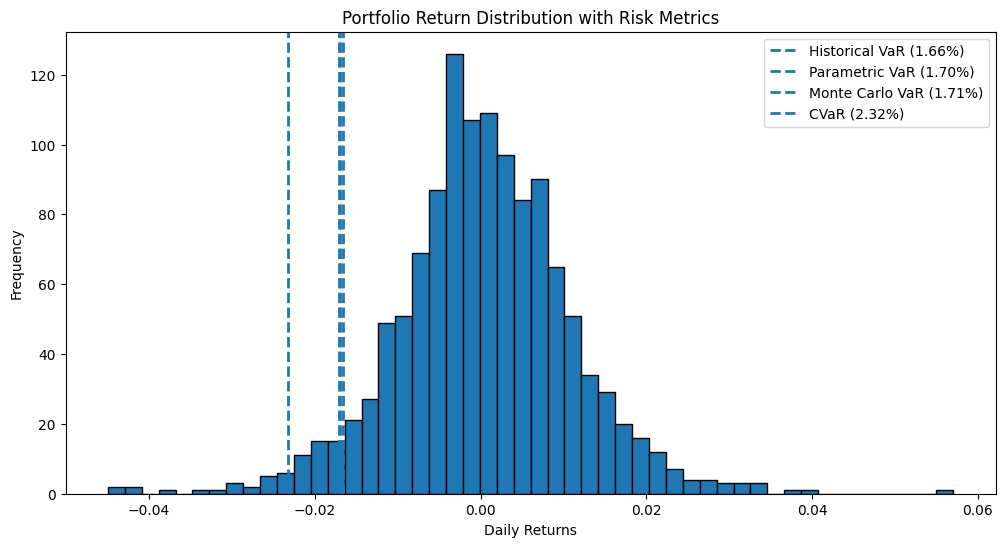

In [25]:
plt.figure(figsize=(12,6))

plt.hist(
    portfolio_returns,
    bins=50,
    edgecolor='black'
)

plt.axvline(
    historical_var_return,
    linestyle='--',
    linewidth=2,
    label=f'Historical VaR ({historical_var:.2%})'
)

plt.axvline(
    parametric_var_return,
    linestyle='--',
    linewidth=2,
    label=f'Parametric VaR ({parametric_var:.2%})'
)

plt.axvline(
    mc_var_return,
    linestyle='--',
    linewidth=2,
    label=f'Monte Carlo VaR ({mc_var:.2%})'
)

plt.axvline(
    cvar_return,
    linestyle='--',
    linewidth=2,
    label=f'CVaR ({cvar:.2%})'
)

plt.title(
    'Portfolio Return Distribution with Risk Metrics'
)

plt.xlabel('Daily Returns')
plt.ylabel('Frequency')

plt.legend()

plt.show()

# Final Project Report

In [26]:
report = pd.DataFrame({
    'Metric': [
        'Mean Daily Return',
        'Daily Volatility',
        'Historical VaR',
        'Parametric VaR',
        'Monte Carlo VaR',
        'Expected Shortfall (CVaR)',
        'Backtesting Breach Rate'
    ],
    'Value': [
        f'{mu:.4%}',
        f'{sigma:.4%}',
        f'{historical_var:.4%}',
        f'{parametric_var:.4%}',
        f'{mc_var:.4%}',
        f'{cvar:.4%}',
        f'{breach_rate:.2f}%'
    ]
})

report

,Metric,Value
0,Mean Daily Return,0.0415%
1,Daily Volatility,1.0567%
2,Historical VaR,1.6635%
3,Parametric VaR,1.6966%
4,Monte Carlo VaR,1.7071%
5,Expected Shortfall (CVaR),2.3249%
6,Backtesting Breach Rate,5.02%
